In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import func

# Generating a synthetic dataset

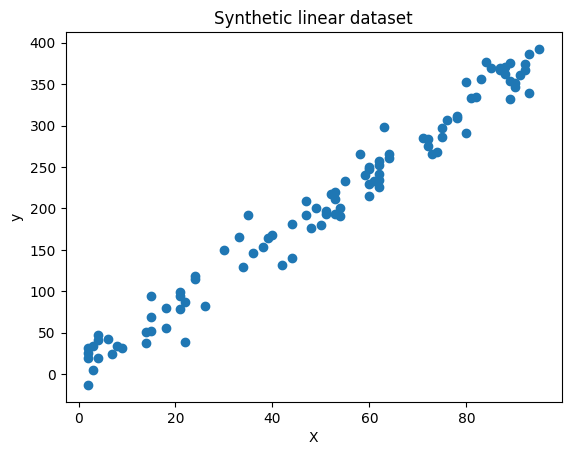

(100, 1)


In [ ]:
np.random.seed(42)
n_sample = 100

X = np.random.randint(1, 100, size=(n_sample, 1))
noise = np.random.normal(0, 20, size=(n_sample, 1))

y = 4 * X + 3 + noise

plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic linear dataset")
plt.show()



We generated a synthetic dataset using: y = 4x + 3 + noise . </br>
The noise is sampled from a normal distribution and centered at 0.

# Training

The cost function measures how far the predictions are from the true values. In linear regression, training means finding the parameters θ that minimize a cost function. </br>
Here we will use the Mean Square Error (MSE) as our cost function.

θ is the vector of values used by the model, it contains the bias term θ₀ and the weights θ₁ to θₙ, which show how important each input value is in the prediction.
</br> So X θ is the dot product of the value vector and the associated weight vector.

## Training with the normal equation

The normal equation is a closed-form solution that directly gives the parameters θ minimizing the MSE for linear regression:

- X θ ≈ y
- Xᵀ X θ = Xᵀ y 
- (Xᵀ X)⁻¹ (Xᵀ X) θ = (Xᵀ X)⁻¹ Xᵀ y
- θ = (Xᵀ X)⁻¹ Xᵀ y

In [70]:
X_b = np.c_[np.ones((n_sample, 1)), X] # Adding intercept (θ₀ = 1)

theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
theta_best

array([[4.66820285],
       [3.95401579]])

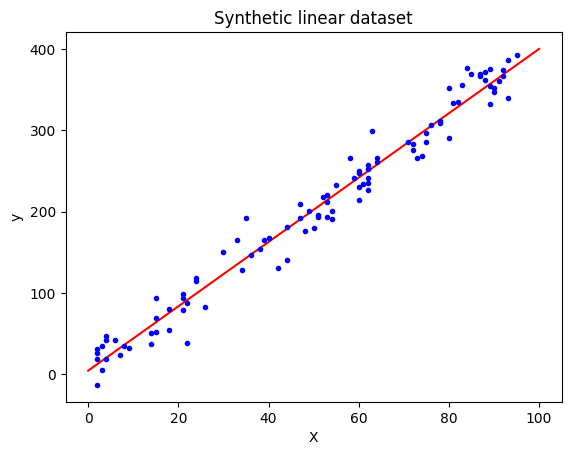

In [71]:
# Test
X_new = np.array([[0], [100]])
X_new_b = np.c_[np.ones((2, 1)), X_new]
y_predict = X_new_b @ theta_best
y_predict

plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic linear dataset")
plt.show()

We have a pretty good fit here ! </br>
Note that the normal equation works for any model that is linear in θ, but it can work for one that is non linear in x such as y = θ₀ + θ₁x + θ₂ sin(x)

Now that the model has been trained, we can evaluate its performance on the training data.

In [72]:
y_train_predict = X_b @ theta_best

mse_normal = np.mean((y - y_train_predict) ** 2)
rmse_normal = np.sqrt(mse_normal) # RMSE is easier to interpret because it is expressed is the same unit as the target.

mse_normal, rmse_normal

(np.float64(361.5602380139437), np.float64(19.014737390086243))

## Training with the gradient descent

The idea is to tweak the parameters iteratively in order to minimize a cost function. <br>
We start with by giving a random value to θ (random initialization) and for every step we take, we try to minimize the loss function, until the algorithm converges to a minimum.

"Fortunately, the MSE cost function for a Linear Regression model happens to be a convex function" Aurelien Geron, Hands on ML

We can compute the gradient for a batch using the formula below:

![description](images/gradient_vector_of_cost_function.png)

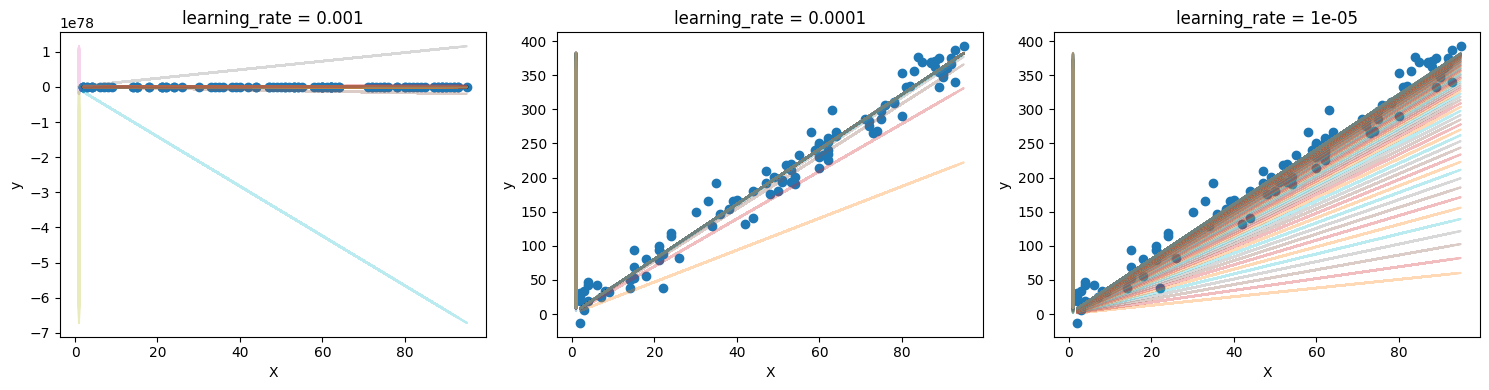

In [89]:
# We try with 3 different learning rates

learning_rates = [0.001, 0.0001, 0.00001]
n_iterations = 100
m = len(X)
cost_history = []

fig, axes = plt.subplots(1, len(learning_rates), figsize=(15, 4))

for ax, learning_rate in zip(axes, learning_rates):
    theta = np.random.randn(2, 1) # random initialization

    ax.scatter(X, y)

    for iteration in range(n_iterations):
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - gradients * learning_rate

        y_predict = X_b @ theta
        
        ax.plot(X_b, y_predict, alpha=0.3)

        # We will use it later to compare with the normal equation
        if learning_rate == 0.00001: 
            mse = func.mean_squared_error(y, y_predict)
            cost_history.append(mse)

    ax.set_xlabel("X")
    ax.set_ylabel("y")
    ax.set_title(f"learning_rate = {learning_rate}")
    

plt.tight_layout()
plt.show()



This is a good visualization of the impact of the learning rate on the training of our model. We can see that on the left that the learning rate is too high and the algorithm jumps all over the place. On the right the algorithm converges but it takes a long time while in the middle it only takes a few step.

To you find a good learning rate, you can do a grid search, just limit the number of iterations beforehand. </br> 
To find a good number of iterations, you can start with a very large number and stop the algorithm when the gradient becomes very tiny. 

Let's compare the results of the normal equation and the gradient descent:

Normal equation RMSE: 19.014737390086243, Gradient descent RMSE: 19.141713501825613


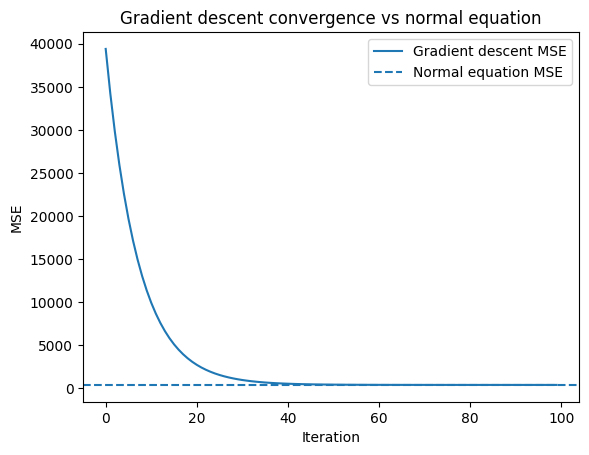

In [92]:
mse_gd = func.mean_squared_error(y, y_predict)
rmse_gd = np.sqrt(mse_gd)
print(f'Normal equation RMSE: {rmse_normal}, Gradient descent RMSE: {rmse_gd}')


plt.plot(cost_history, label="Gradient descent MSE")
plt.axhline(y=mse_normal, linestyle="--", label="Normal equation MSE")

plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Gradient descent convergence vs normal equation")
plt.legend()
plt.show()

For visualization purposes I chose the smallest learning rate out of the three we tested. </br>
With a higher learning rate, gradient descent can converge so quickly that most of the decrease happens in the first few iterations

# Trying the library

To make it easier to experiment with different parameters and hyper-parameters we will use the functions defined in the .py file

In [1]:
from LinearRegression import LinearRegression
import pandas as pd
import numpy as np

X = np.random.randint(1, 100, size=100)
y = 4 * X

ne_model = LinearRegression(solver='ne').fit(X, y)
bgd_model = LinearRegression(solver='bgd', learning_rate=0.00001, n_iterations=100).fit(X, y)
sgd_model = LinearRegression(solver='sgd', learning_rate=0.00001, n_iterations=100).fit(X, y)

print(ne_model.theta)
print(bgd_model.theta)
print(sgd_model.theta)

[[1.63424829e-13]
 [4.00000000e+00]]
[[-0.39551673]
 [ 4.00241517]]
[[-0.37466345]
 [ 4.00499743]]


In [7]:
X = np.array([1, 2, 3, 4, 5])
y = np.array([3, 5, 7, 9, 11])

X_test = np.array([6, 7, 8])

mod = LinearRegression(solver='bgd', learning_rate=0.001, n_iterations=100000).fit(X, y)

print(mod.predict(X_test))

[[13.]
 [15.]
 [17.]]
